<a href="https://colab.research.google.com/github/kandalavanshika-code/ML-project/blob/main/Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

STEP 0 — Install required **libraries**

In [2]:
!pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn shap lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 16.2 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4120 sha256=b3f8d077fece4e39d42d48cff67a3f66993d0df006d7f4747fae945b8db0b67e
  Stored in directory: /root/.cache/pip/wheels/7e/16/46/9477f188924292d3bf1fb8fb42844201591abfc19b7ba6d868
Successfully built autograd-gamma


STEP 1 — Import libraries

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    VotingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import shap

from lifelines import KaplanMeierFitter
from lifelines import CoxPHFitter

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

STEP 2 — Load the dataset

In [5]:
file_path = "/content/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


STEP 3 — Understand the dataset

In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Number of rows: 7043
Number of columns: 21

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


STEP 4 — Check missing values

In [7]:
print("Missing values in each column:\n")
print(df.isnull().sum())
print("\nBlank values in TotalCharges:")
print((df["TotalCharges"].astype(str).str.strip() == "").sum())

Missing values in each column:

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Blank values in TotalCharges:
11


STEP 5 — Convert TotalCharges to numeric

In [8]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print(df["TotalCharges"].dtype)

print("\nMissing TotalCharges after conversion:")
print(df["TotalCharges"].isnull().sum())

float64

Missing TotalCharges after conversion:
11


STEP 6 — Handle missing values

In [9]:
print("Rows before removing missing values:", len(df))

df = df.dropna(subset=["TotalCharges"])

print("Rows after removing missing values:", len(df))

Rows before removing missing values: 7043
Rows after removing missing values: 7032


STEP 7 — Check duplicates

In [10]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

print("Shape after duplicate removal:", df.shape)

Duplicate rows: 0
Shape after duplicate removal: (7032, 21)


STEP 8 — Remove customerID from machine learning

In [11]:
customer_ids = df["customerID"].copy()

df_model = df.drop(columns=["customerID"])

print("customerID removed from model features.")
print("New shape:", df_model.shape)

customerID removed from model features.
New shape: (7032, 20)


STEP 9 — Convert target variable

In [12]:
df_model["Churn"] = df_model["Churn"].map({
    "Yes": 1,
    "No": 0
})

print(df_model["Churn"].value_counts())

Churn
0    5163
1    1869
Name: count, dtype: int64


STEP 10 — Explore churn distribution

Churn
0    5163
1    1869
Name: count, dtype: int64


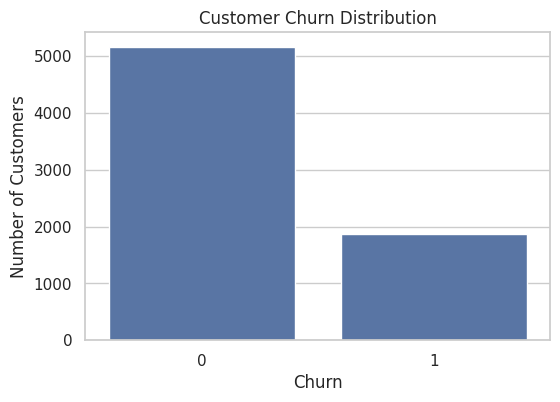

In [13]:
churn_counts = df_model["Churn"].value_counts()

print(churn_counts)

plt.figure(figsize=(6,4))
sns.countplot(x=df_model["Churn"])
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

STEP 11 — Feature engineering

11.1 Average monthly spending consistency

In [14]:
df_model["AvgMonthlySpend"] = (
    df_model["TotalCharges"] /
    df_model["tenure"].replace(0, 1)
)

print(df_model[
    ["tenure", "MonthlyCharges", "TotalCharges", "AvgMonthlySpend"]
].head())

   tenure  MonthlyCharges  TotalCharges  AvgMonthlySpend
0       1           29.85         29.85        29.850000
1      34           56.95       1889.50        55.573529
2       2           53.85        108.15        54.075000
3      45           42.30       1840.75        40.905556
4       2           70.70        151.65        75.825000


11.2 Total services subscribed

In [15]:
service_columns = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

def count_services(row):
    count = 0

    for col in service_columns:
        if row[col] == "Yes":
            count += 1

    return count

df_model["TotalServices"] = df_model.apply(
    count_services,
    axis=1
)

print(df_model["TotalServices"].value_counts().sort_index())

TotalServices
0      80
1    1697
2    1186
3     965
4     921
5     906
6     674
7     395
8     208
Name: count, dtype: int64


STEP 12 — Create customer value feature

In [16]:
df_model["CustomerValue"] = (
    df_model["MonthlyCharges"] *
    (1 + np.log1p(df_model["tenure"]))
)

print(
    df_model[
        ["MonthlyCharges", "tenure", "CustomerValue"]
    ].head()
)

   MonthlyCharges  tenure  CustomerValue
0           29.85       1      50.540443
1           56.95      34     259.427072
2           53.85       2     113.010272
3           42.30      45     204.251531
4           70.70       2     148.371889


STEP 13 — Separate X and y

In [17]:
X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (7032, 22)
Target: (7032,)


STEP 14 — Identify numerical and categorical features

In [18]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend', 'TotalServices', 'CustomerValue']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


STEP 15 — Train/test split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 5625
Testing samples: 1407


STEP 16 — Preprocessing pipeline

In [20]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

STEP 17 — Create base ML models

In [21]:
lr = LogisticRegression(
    max_iter=2000,
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

STEP 18 — Create ensemble model

In [22]:
ensemble = VotingClassifier(
    estimators=[
        ("lr", lr),
        ("rf", rf),
        ("gb", gb)
    ],
    voting="soft"
)

print("Soft Voting Ensemble created.")

Soft Voting Ensemble created.


STEP 19 — Add SMOTE to the ML pipeline

In [23]:
model_pipeline = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(
            random_state=42
        )),
        ("model", ensemble)
    ]
)

STEP 20 — Train the churn prediction model

In [24]:
print("Training model...")

model_pipeline.fit(
    X_train,
    y_train
)

print("Model training completed.")

Training model...
Model training completed.


STEP 21 — Predict churn

In [25]:
y_pred = model_pipeline.predict(X_test)

y_prob = model_pipeline.predict_proba(X_test)[:, 1]

print("First 10 predictions:")
print(y_pred[:10])

print("\nFirst 10 churn probabilities:")
print(y_prob[:10])

First 10 predictions:
[0 1 0 0 0 1 0 0 1 0]

First 10 churn probabilities:
[0.02398231 0.7763811  0.01838821 0.31289605 0.21541147 0.54054513
 0.05501828 0.30149498 0.83013081 0.03210772]


STEP 22 — Evaluate the model

In [26]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("MODEL PERFORMANCE")
print("-----------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(auc, 4))

MODEL PERFORMANCE
-----------------
Accuracy : 0.7669
Precision: 0.5483
Recall   : 0.6979
F1 Score : 0.6141
ROC-AUC  : 0.834


STEP 23 — Classification report

In [27]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Churn", "Churn"]
    )
)

              precision    recall  f1-score   support

    No Churn       0.88      0.79      0.83      1033
       Churn       0.55      0.70      0.61       374

    accuracy                           0.77      1407
   macro avg       0.71      0.74      0.72      1407
weighted avg       0.79      0.77      0.77      1407



STEP 24 — Confusion matrix

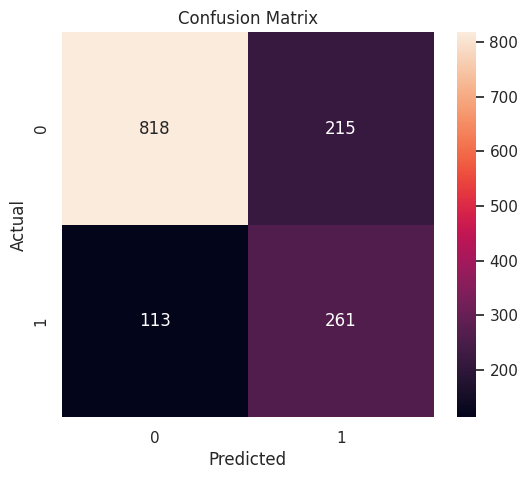

In [28]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

STEP 25 — Create prediction dataset

In [29]:
results = X_test.copy()

results["ActualChurn"] = y_test.values
results["PredictedChurn"] = y_pred
results["ChurnProbability"] = y_prob

results["CustomerID"] = customer_ids.loc[
    X_test.index
].values

print(results[
    [
        "CustomerID",
        "ChurnProbability",
        "PredictedChurn",
        "ActualChurn"
    ]
].head(10))

      CustomerID  ChurnProbability  PredictedChurn  ActualChurn
974   0604-THJFP          0.023982               0            0
619   4059-IIEBK          0.776381               1            0
4289  2228-BZDEE          0.018388               0            0
3721  2839-RFSQE          0.312896               0            1
4533  5360-LJCNJ          0.215411               0            0
445   7752-XUSCI          0.540545               1            1
5898  8277-RVRSV          0.055018               0            0
3387  3530-CRZSB          0.301495               0            0
1346  2845-HSJCY          0.830131               1            1
5690  0336-KXKFK          0.032108               0            0


STEP 26 — Create churn risk categories

In [30]:
def risk_category(probability):

    if probability < 0.30:
        return "Low"

    elif probability < 0.60:
        return "Medium"

    else:
        return "High"

results["RiskCategory"] = results[
    "ChurnProbability"
].apply(risk_category)

print(
    results["RiskCategory"].value_counts()
)

RiskCategory
Low       712
High      362
Medium    333
Name: count, dtype: int64


STEP 27 — EXPLAINABLE AI using SHAP

In [31]:
fitted_preprocessor = model_pipeline.named_steps[
    "preprocessor"
]

fitted_ensemble = model_pipeline.named_steps[
    "model"
]

rf_model = fitted_ensemble.named_estimators_[
    "rf"
]

STEP 28 — Transform test data

In [32]:
X_test_transformed = fitted_preprocessor.transform(
    X_test
)

feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)

print(
    "Number of transformed features:",
    len(feature_names)
)

Number of transformed features: 48


STEP 29 — Generate SHAP values

In [33]:
explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_test_transformed)

print(type(shap_values))

# shap_values can be a list of arrays (one for each class) or a single 3D array.
# For tree models, it's often a list if the model has multiple outputs.
# However, the output shows it's a single numpy.ndarray of shape (1407, 48, 2),
# where the last dimension represents the output classes (e.g., 0 for no churn, 1 for churn).

# If it's a list, shap_values[1] would be the SHAP values for the positive class.
# If it's a 3D numpy array, shap_values[:, :, 1] would be the SHAP values for the positive class.
# Based on the previous output, it's a 3D numpy array.

if isinstance(shap_values, list):
    # This path is taken if explainer.shap_values returns a list of arrays.
    # In this case, shap_values[1] would be the SHAP values for the positive class.
    print("SHAP values shape:",
          shap_values[1].shape)
    shap_churn = shap_values[1]
else:
    # This path is taken if explainer.shap_values returns a single 3D numpy array.
    # The last dimension [:, :, 1] corresponds to the positive class (Churn=1).
    print("SHAP values shape:",
          shap_values.shape)
    shap_churn = shap_values[:, :, 1]

# Verify the shape of shap_churn after selection
print("Shape of shap_churn (for positive class):", shap_churn.shape)

<class 'numpy.ndarray'>
SHAP values shape: (1407, 48, 2)
Shape of shap_churn (for positive class): (1407, 48)


STEP 30 — Global SHAP explanation

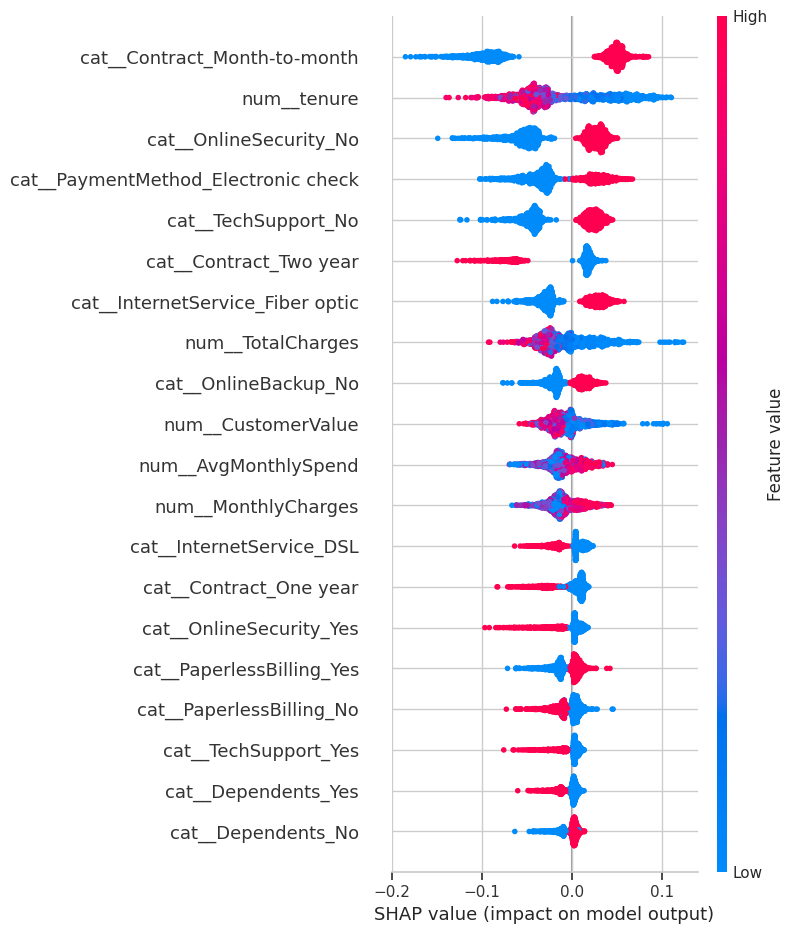

In [34]:
shap.summary_plot(
    shap_churn,
    X_test_transformed,
    feature_names=feature_names,
    show=True
)

STEP 31 — SHAP feature importance table

In [35]:
mean_shap = np.abs(
    shap_churn
).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "MeanAbsoluteSHAP": mean_shap
})

shap_importance = shap_importance.sort_values(
    "MeanAbsoluteSHAP",
    ascending=False
)

display(
    shap_importance.head(15)
)

,Feature,MeanAbsoluteSHAP
39,cat__Contract_Month-to-month,0.070070
1,num__tenure,0.044282
21,cat__OnlineSecurity_No,0.041481
46,cat__PaymentMethod_Electronic check,0.035547
30,cat__TechSupport_No,0.035346
41,cat__Contract_Two year,0.030460
19,cat__InternetService_Fiber optic,0.030042
3,num__TotalCharges,0.025345
24,cat__OnlineBackup_No,0.017837
6,num__CustomerValue,0.016525


STEP 32 — Individual customer explanation

In [36]:
highest_risk_position = np.argmax(y_prob)

customer_index = X_test.index[
    highest_risk_position
]

customer_data = X_test.loc[
    customer_index
]

customer_id = customer_ids.loc[
    customer_index
]

print("Customer ID:", customer_id)
print("Churn probability:",
      round(y_prob[highest_risk_position], 4))

display(
    customer_data.to_frame()
)

Customer ID: 9057-SIHCH
Churn probability: 0.9566


,3727
gender,Female
SeniorCitizen,0
Partner,No
Dependents,No
tenure,3
PhoneService,Yes
MultipleLines,Yes
InternetService,Fiber optic
OnlineSecurity,No
OnlineBackup,No


STEP 33 — Explain that individual customer

In [37]:
individual_shap = shap_churn[
    highest_risk_position
]

individual_explanation = pd.DataFrame({
    "Feature": feature_names,
    "SHAP_Value": individual_shap,
    "Absolute_SHAP": np.abs(individual_shap)
})

individual_explanation = (
    individual_explanation
    .sort_values(
        "Absolute_SHAP",
        ascending=False
    )
)

display(
    individual_explanation.head(10)
)

,Feature,SHAP_Value,Absolute_SHAP
39,cat__Contract_Month-to-month,0.053753,0.053753
1,num__tenure,0.052323,0.052323
19,cat__InternetService_Fiber optic,0.036494,0.036494
21,cat__OnlineSecurity_No,0.028796,0.028796
30,cat__TechSupport_No,0.025947,0.025947
46,cat__PaymentMethod_Electronic check,0.025850,0.025850
4,num__AvgMonthlySpend,0.023985,0.023985
2,num__MonthlyCharges,0.023026,0.023026
3,num__TotalCharges,0.020607,0.020607
18,cat__InternetService_DSL,0.018235,0.018235


STEP 34 — CUSTOMER SEGMENTATION

In [38]:
segmentation_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "AvgMonthlySpend",
    "TotalServices",
    "CustomerValue"
]

segmentation_data = df_model[
    segmentation_features
].copy()

segmentation_data = segmentation_data.replace(
    [np.inf, -np.inf],
    np.nan
)

segmentation_data = segmentation_data.fillna(
    segmentation_data.median()
)

scaler = StandardScaler()

segmentation_scaled = scaler.fit_transform(
    segmentation_data
)

print(
    "Segmentation data shape:",
    segmentation_scaled.shape
)

Segmentation data shape: (7032, 7)


STEP 35 — Find suitable number of clusters

In [39]:
silhouette_scores = []

K_values = range(2, 7)

for k in K_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(
        segmentation_scaled
    )

    score = silhouette_score(
        segmentation_scaled,
        labels
    )

    silhouette_scores.append(score)

    print(
        "K =", k,
        "Silhouette Score =",
        round(score, 4)
    )

K = 2 Silhouette Score = 0.4139
K = 3 Silhouette Score = 0.362
K = 4 Silhouette Score = 0.3921
K = 5 Silhouette Score = 0.4059
K = 6 Silhouette Score = 0.38


STEP 36 — Plot cluster selection

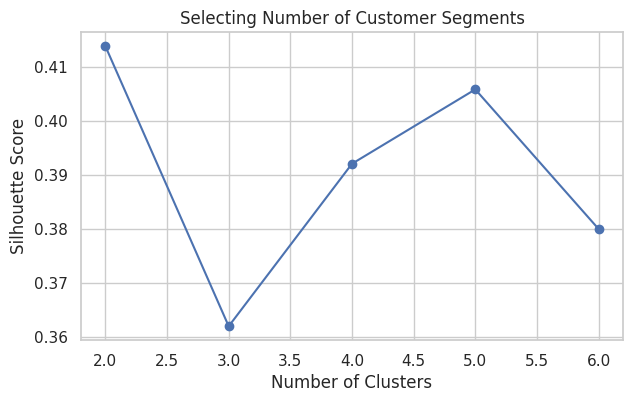

In [40]:
plt.figure(figsize=(7,4))

plt.plot(
    list(K_values),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Selecting Number of Customer Segments")

plt.show()

STEP 37 — Perform customer segmentation

In [41]:
optimal_k = 4
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

df_model["CustomerSegment"] = kmeans.fit_predict(
    segmentation_scaled
)

print(
    df_model["CustomerSegment"].value_counts()
)

CustomerSegment
2    2261
1    2184
3    1766
0     821
Name: count, dtype: int64


STEP 38 — Understand each segment

In [42]:
segment_profile = df_model.groupby(
    "CustomerSegment"
)[
    segmentation_features + ["Churn"]
].mean()

display(segment_profile)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,AvgMonthlySpend,TotalServices,CustomerValue,Churn
CustomerSegment,,,,,,,,
0,1.000000,24.911084,79.127162,1971.451096,78.934709,3.408039,304.827591,0.493301
1,0.000000,20.181319,74.165568,1403.749428,74.208113,3.391484,265.959437,0.386447
2,0.037594,25.706767,27.496174,647.102720,27.466637,1.332596,98.431146,0.160548
3,0.133635,59.648358,94.309824,5610.826359,94.389335,5.907701,478.962870,0.145527


STEP 39 — Add segment information to prediction results

In [43]:
results["CustomerSegment"] = df_model.loc[
    results.index,
    "CustomerSegment"
]

display(
    results[
        [
            "CustomerID",
            "ChurnProbability",
            "RiskCategory",
            "CustomerSegment"
        ]
    ].head(10)
)

,CustomerID,ChurnProbability,RiskCategory,CustomerSegment
974,0604-THJFP,0.023982,Low,3
619,4059-IIEBK,0.776381,High,1
4289,2228-BZDEE,0.018388,Low,2
3721,2839-RFSQE,0.312896,Medium,2
4533,5360-LJCNJ,0.215411,Low,3
445,7752-XUSCI,0.540545,Medium,3
5898,8277-RVRSV,0.055018,Low,2
3387,3530-CRZSB,0.301495,Medium,2
1346,2845-HSJCY,0.830131,High,1
5690,0336-KXKFK,0.032108,Low,3


STEP 40 — TIME-AWARE CHURN ANALYSIS
This implements the new time-aware technology.

The dataset gives us:

tenure
+
churn status

Therefore:

tenure = observed duration
Churn = event

We can use survival analysis to investigate churn timing.

STEP 41 — Kaplan-Meier survival analysis

In [44]:
survival_df = df_model[
    ["tenure", "Churn"]
].copy()

kmf = KaplanMeierFitter()

kmf.fit(
    durations=survival_df["tenure"],
    event_observed=survival_df["Churn"]
)

print(
    "Median survival time:",
    kmf.median_survival_time_
)

Median survival time: inf


STEP 42 — Plot survival curve

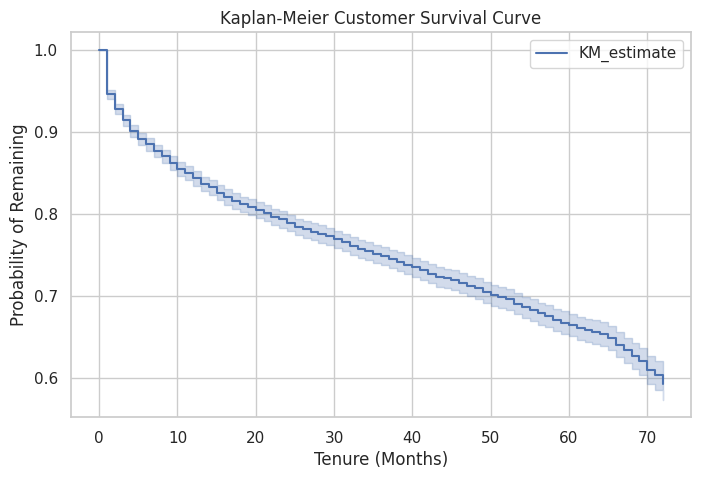

In [45]:
plt.figure(figsize=(8,5))

kmf.plot_survival_function()

plt.title(
    "Kaplan-Meier Customer Survival Curve"
)

plt.xlabel("Tenure (Months)")
plt.ylabel("Probability of Remaining")

plt.show()


STEP 43 — Survival analysis by contract

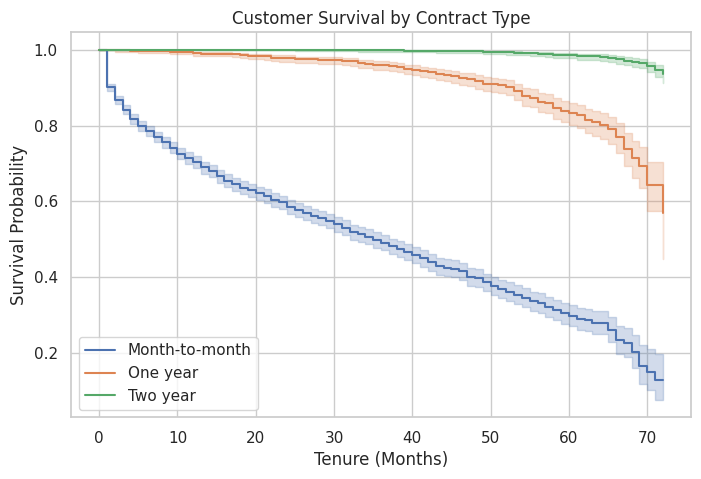

In [46]:
plt.figure(figsize=(8,5))

for contract_type in df_model["Contract"].unique():

    mask = df_model["Contract"] == contract_type

    km = KaplanMeierFitter()

    km.fit(
        df_model.loc[mask, "tenure"],
        event_observed=df_model.loc[mask, "Churn"],
        label=contract_type
    )

    km.plot_survival_function()

plt.title(
    "Customer Survival by Contract Type"
)

plt.xlabel("Tenure (Months)")
plt.ylabel("Survival Probability")

plt.show()

STEP 44 — Cox Proportional Hazards model

In [47]:
cox_columns = [
    "tenure",
    "Churn",
    "MonthlyCharges",
    "TotalCharges",
    "SeniorCitizen",
    "CustomerValue",
    "TotalServices"
]

cox_df = df_model[
    cox_columns
].copy()

cox_df = cox_df.replace(
    [np.inf, -np.inf],
    np.nan
)

cox_df = cox_df.dropna()

cph = CoxPHFitter()

cph.fit(
    cox_df,
    duration_col="tenure",
    event_col="Churn"
)

cph.print_summary()

<lifelines.CoxPHFitter: fitted with 7032 total observations, 5163 right-censored observations>
             duration col = 'tenure'
                event col = 'Churn'
      baseline estimation = breslow
   number of observations = 7032
number of events observed = 1869
   partial log-likelihood = -14639.91
         time fit was run = 2026-09-15 04:45:10 UTC

---
                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                       
MonthlyCharges  0.04      1.04      0.00            0.04            0.05                1.04                1.05
TotalCharges    0.00      1.00      0.00            0.00            0.00                1.00                1.00
SeniorCitizen   0.05      1.05      0.06           -0.07            0.17                0.93                1.19
CustomerValue  -0.01      0.99      0.00           -0.01           -0.01                0.99                0.99
TotalServices  -0.04      0.97      0.02           -0.08            0.01                0.92                1.01

                cmp to      z      p  -log2(p)
covariate                                     
MonthlyCharges    0.00  13.27 <0.005    131.04
TotalCharges      0.00   4.73 <0.005     18.79
SeniorCitizen     0.00   0.79   0.43      1.22
CustomerValue     0.00 -10.33 <0.005     80.70
TotalServices     0.00  -1.53   0.13      3.00
---
Concordance = 0.94
Partial AIC = 29289.81
log-likelihood ratio test = 2026.27 on 5 df
-log2(p) of ll-ratio test = inf

STEP 45 — Cox model visualization

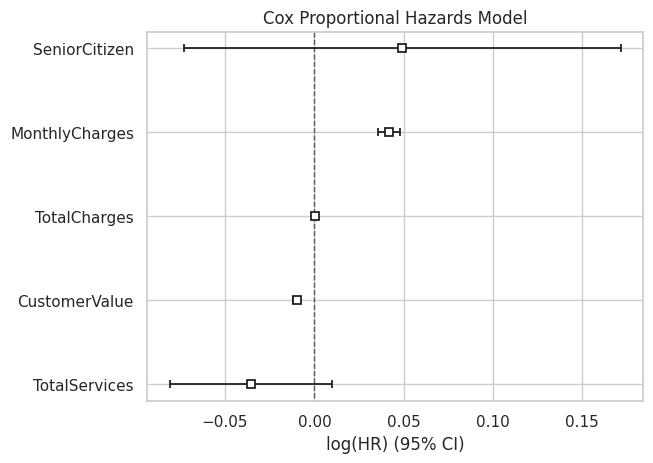

In [48]:
cph.plot()

plt.title(
    "Cox Proportional Hazards Model"
)

plt.show()

STEP 46 — Estimate individual survival probability

In [49]:
cox_customer_features = cox_df.drop(
    columns=["tenure", "Churn"]
)

individual_survival = cph.predict_survival_function(
    cox_customer_features
)

print(
    individual_survival.iloc[:, :5]
)

             0         1         2         3         4
1.0   0.934512  0.966164  0.910474  0.968535  0.865547
2.0   0.908742  0.952530  0.875892  0.955835  0.815456
3.0   0.887534  0.941167  0.847713  0.945240  0.775419
4.0   0.867757  0.930449  0.821668  0.935238  0.739046
5.0   0.851845  0.921739  0.800878  0.927104  0.710455
...        ...       ...       ...       ...       ...
68.0  0.422396  0.645333  0.303189  0.665778  0.159250
69.0  0.413074  0.638055  0.293963  0.658802  0.151850
70.0  0.398784  0.626740  0.279974  0.647943  0.140870
71.0  0.389527  0.619303  0.271016  0.640800  0.133990
72.0  0.376278  0.608507  0.258335  0.630418  0.124461

[72 rows x 5 columns]


STEP 47 — Create a time-risk score

In [50]:
survival_at_12 = cph.predict_survival_function(
    cox_customer_features,
    times=[12]
).T

survival_at_12.columns = [
    "SurvivalProbability12M"
]

survival_at_12["TimeRiskScore"] = (
    1 -
    survival_at_12["SurvivalProbability12M"]
)

display(
    survival_at_12.head()
)

,SurvivalProbability12M,TimeRiskScore
0,0.771551,0.228449
1,0.876509,0.123491
2,0.698276,0.301724
3,0.884775,0.115225
4,0.575273,0.424727


STEP 48 — Combine prediction and survival information

In [51]:
time_risk_lookup = survival_at_12.copy()

time_risk_lookup["CustomerIndex"] = (
    time_risk_lookup.index
)

time_risk_lookup = time_risk_lookup.reset_index(
    drop=True
)
all_cox_features = df_model[
    [
        "MonthlyCharges",
        "TotalCharges",
        "SeniorCitizen",
        "CustomerValue",
        "TotalServices"
    ]
].copy()

all_survival = cph.predict_survival_function(
    all_cox_features,
    times=[12]
).T

all_survival.columns = [
    "SurvivalProbability12M"
]

all_survival["TimeRiskScore"] = (
    1 -
    all_survival["SurvivalProbability12M"]
)

all_survival.head()

,SurvivalProbability12M,TimeRiskScore
0,0.771551,0.228449
1,0.876509,0.123491
2,0.698276,0.301724
3,0.884775,0.115225
4,0.575273,0.424727


STEP 49 — Add time risk to customer dataset

In [52]:
df_model["SurvivalProbability12M"] = (
    all_survival["SurvivalProbability12M"]
    .values
)

df_model["TimeRiskScore"] = (
    all_survival["TimeRiskScore"]
    .values
)

print(
    df_model[
        [
            "tenure",
            "Churn",
            "SurvivalProbability12M",
            "TimeRiskScore"
        ]
    ].head()
)

   tenure  Churn  SurvivalProbability12M  TimeRiskScore
0       1      0                0.771551       0.228449
1      34      0                0.876509       0.123491
2       2      1                0.698276       0.301724
3      45      0                0.884775       0.115225
4       2      1                0.575273       0.424727


STEP 50 — Build integrated customer risk profile

This is the central part of your proposed research.

We combine:

Churn probability
+
SHAP explanation
+
Customer segment
+
Time risk
+
Customer value

In [53]:
customer_profile = df_model[
    [
        "gender",
        "SeniorCitizen",
        "Partner",
        "Dependents",
        "tenure",
        "PhoneService",
        "MultipleLines",
        "InternetService",
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "TechSupport",
        "StreamingTV",
        "StreamingMovies",
        "Contract",
        "PaperlessBilling",
        "PaymentMethod",
        "MonthlyCharges",
        "TotalCharges",
        "AvgMonthlySpend",
        "TotalServices",
        "CustomerValue",
        "CustomerSegment",
        "SurvivalProbability12M",
        "TimeRiskScore",
        "Churn"
    ]
].copy()

customer_profile["ChurnProbability"] = np.nan
customer_profile["RiskCategory"] = "Not Evaluated"

for idx, prob, risk in zip(
    X_test.index,
    y_prob,
    results["RiskCategory"]
):

    customer_profile.loc[
        idx,
        "ChurnProbability"
    ] = prob

    customer_profile.loc[
        idx,
        "RiskCategory"
    ] = risk

STEP 51 — Create intervention timing

In [54]:
def intervention_window(row):

    if row["ChurnProbability"] >= 0.75:
        return "Immediate"

    elif row["ChurnProbability"] >= 0.60:
        return "Within 1 month"

    elif row["ChurnProbability"] >= 0.40:
        return "Within 3 months"

    else:
        return "Routine monitoring"

customer_profile["InterventionWindow"] = (
    customer_profile.apply(
        intervention_window,
        axis=1
    )
)

STEP 52 — PERSONALISE RETENTION RECOMMENDATIONS

In [55]:
def retention_recommendation(row):

    if row["Contract"] == "Month-to-month":
        return "Offer contract upgrade incentive"

    elif row["TechSupport"] == "No":
        return "Offer technical support package"

    elif row["MonthlyCharges"] > 80:
        return "Offer personalised pricing or loyalty discount"

    elif row["tenure"] < 12:
        return "Offer early-tenure loyalty benefit"

    elif row["InternetService"] == "Fiber optic":
        return "Offer fibre service optimisation/support"

    elif row["TotalServices"] <= 2:
        return "Offer relevant bundled services"

    else:
        return "Offer personalised loyalty communication"


customer_profile[
    "RetentionRecommendation"
] = customer_profile.apply(
    retention_recommendation,
    axis=1
)

STEP 53 — Make recommendations risk-aware

In [56]:
def risk_based_action(row):

    if row["RiskCategory"] == "High":
        return row["RetentionRecommendation"]

    elif row["RiskCategory"] == "Medium":
        return "Low-cost personalised engagement"

    elif row["RiskCategory"] == "Low":
        return "Loyalty monitoring"

    else:
        return "No action"

customer_profile[
    "RecommendedAction"
] = customer_profile.apply(
    risk_based_action,
    axis=1
)

STEP 54 — COST-AWARE DECISION ENGINE

In [57]:
INTERVENTION_COST = 20

RETENTION_BENEFIT_RATE = 0.30

STEP 55 — Estimate expected retention benefit

In [58]:
customer_profile[
    "ExpectedRetentionBenefit"
] = (
    customer_profile["ChurnProbability"]
    *
    customer_profile["CustomerValue"]
    *
    RETENTION_BENEFIT_RATE
)

STEP 56 — Calculate intervention cost

In [59]:
customer_profile[
    "InterventionCost"
] = INTERVENTION_COST

STEP 57 — Calculate expected net benefit

In [60]:
customer_profile[
    "ExpectedNetBenefit"
] = (
    customer_profile["ExpectedRetentionBenefit"]
    -
    customer_profile["InterventionCost"]
)

STEP 58 — Create intervention priority

In [61]:
customer_profile[
    "PriorityScore"
] = (
    0.40 *
    customer_profile["ChurnProbability"]

    +

    0.25 *
    customer_profile["TimeRiskScore"]

    +

    0.20 *
    (
        customer_profile["CustomerValue"] /
        customer_profile["CustomerValue"].max()
    )

    +

    0.15 *
    (
        customer_profile["ExpectedNetBenefit"] /
        (
            customer_profile["ExpectedNetBenefit"]
            .abs()
            .max()
            + 1e-9
        )
    )
)

STEP 59 — Final intervention decision

In [62]:
def final_decision(row):

    if row["RiskCategory"] == "High":

        if row["ExpectedNetBenefit"] > 0:
            return "PRIORITY RETENTION"

        else:
            return "HIGH RISK - LOW ECONOMIC RETURN"

    elif row["RiskCategory"] == "Medium":

        return "LOW-COST RETENTION"

    else:

        return "MONITOR"

customer_profile[
    "FinalDecision"
] = customer_profile.apply(
    final_decision,
    axis=1
)

STEP 60 — Final customer-level output

In [63]:
final_columns = [
    "ChurnProbability",
    "RiskCategory",
    "CustomerSegment",
    "SurvivalProbability12M",
    "TimeRiskScore",
    "InterventionWindow",
    "RetentionRecommendation",
    "ExpectedRetentionBenefit",
    "InterventionCost",
    "ExpectedNetBenefit",
    "PriorityScore",
    "FinalDecision"
]

display(
    customer_profile[
        final_columns
    ].head(20)
)

,ChurnProbability,RiskCategory,CustomerSegment,SurvivalProbability12M,TimeRiskScore,InterventionWindow,RetentionRecommendation,ExpectedRetentionBenefit,InterventionCost,ExpectedNetBenefit,PriorityScore,FinalDecision
0,NaN,Not Evaluated,2,0.771551,0.228449,Routine monitoring,Offer contract upgrade incentive,NaN,20,NaN,NaN,MONITOR
1,NaN,Not Evaluated,1,0.876509,0.123491,Routine monitoring,Offer technical support package,NaN,20,NaN,NaN,MONITOR
2,NaN,Not Evaluated,1,0.698276,0.301724,Routine monitoring,Offer contract upgrade incentive,NaN,20,NaN,NaN,MONITOR
3,NaN,Not Evaluated,2,0.884775,0.115225,Routine monitoring,Offer personalised loyalty communication,NaN,20,NaN,NaN,MONITOR
4,NaN,Not Evaluated,1,0.575273,0.424727,Routine monitoring,Offer contract upgrade incentive,NaN,20,NaN,NaN,MONITOR
5,NaN,Not Evaluated,1,0.714985,0.285015,Routine monitoring,Offer contract upgrade incentive,NaN,20,NaN,NaN,MONITOR
6,0.530179,Medium,1,0.846121,0.153879,Within 3 months,Offer contract upgrade incentive,58.606958,20,38.606958,0.424198,LOW-COST RETENTION
7,0.358855,Medium,2,0.848345,0.151655,Routine monitoring,Offer contract upgrade incentive,10.882701,20,-9.117299,0.200328,LOW-COST RETENTION
8,NaN,Not Evaluated,3,0.860260,0.139740,Routine monitoring,Offer contract upgrade incentive,NaN,20,NaN,NaN,MONITOR
9,0.032713,Low,1,0.881121,0.118879,Routine monitoring,Offer technical support package,2.834163,20,-17.165837,0.109684,MONITOR


STEP 61 — Find highest-priority customers

In [64]:
priority_customers = customer_profile[
    customer_profile["FinalDecision"]
    == "PRIORITY RETENTION"
].copy()

priority_customers = priority_customers.sort_values(
    "PriorityScore",
    ascending=False
)

print(
    "Number of priority customers:",
    len(priority_customers)
)

display(
    priority_customers[
        final_columns
    ].head(20)
)

Number of priority customers: 315


,ChurnProbability,RiskCategory,CustomerSegment,SurvivalProbability12M,TimeRiskScore,InterventionWindow,RetentionRecommendation,ExpectedRetentionBenefit,InterventionCost,ExpectedNetBenefit,PriorityScore,FinalDecision
38,0.830907,High,3,0.873959,0.126041,Immediate,Offer contract upgrade incentive,120.762682,20,100.762682,0.665181,PRIORITY RETENTION
6009,0.789818,High,3,0.879130,0.120870,Immediate,Offer contract upgrade incentive,122.762857,20,102.762857,0.661083,PRIORITY RETENTION
6839,0.930572,High,1,0.764080,0.235920,Immediate,Offer contract upgrade incentive,98.018332,20,78.018332,0.656863,PRIORITY RETENTION
2631,0.945363,High,0,0.681587,0.318413,Immediate,Offer contract upgrade incentive,86.680721,20,66.680721,0.652379,PRIORITY RETENTION
3063,0.829930,High,3,0.871399,0.128601,Immediate,Offer contract upgrade incentive,115.523928,20,95.523928,0.651267,PRIORITY RETENTION
3380,0.955634,High,0,0.283419,0.716581,Immediate,Offer contract upgrade incentive,46.162375,20,26.162375,0.650847,PRIORITY RETENTION
2516,0.906926,High,0,0.802018,0.197982,Immediate,Offer contract upgrade incentive,100.538643,20,80.538643,0.647463,PRIORITY RETENTION
3910,0.767598,High,3,0.880048,0.119952,Immediate,Offer contract upgrade incentive,119.352892,20,99.352892,0.647049,PRIORITY RETENTION
3545,0.814183,High,3,0.878637,0.121363,Immediate,Offer contract upgrade incentive,115.282339,20,95.282339,0.645347,PRIORITY RETENTION
3727,0.956597,High,1,0.513891,0.486109,Immediate,Offer contract upgrade incentive,66.153293,20,46.153293,0.644919,PRIORITY RETENTION


STEP 62 — Business action summary

In [65]:
print(
    customer_profile[
        "FinalDecision"
    ].value_counts()
)
print(
    customer_profile[
        "RecommendedAction"
    ].value_counts()
)


FinalDecision
MONITOR                            6337
LOW-COST RETENTION                  333
PRIORITY RETENTION                  315
HIGH RISK - LOW ECONOMIC RETURN      47
Name: count, dtype: int64
RecommendedAction
No action                           5625
Loyalty monitoring                   712
Offer contract upgrade incentive     362
Low-cost personalised engagement     333
Name: count, dtype: int64


STEP 63 — Analyse risk by customer segment

In [66]:
segment_risk = customer_profile.groupby(
    "CustomerSegment"
).agg(
    AverageChurnProbability=(
        "ChurnProbability",
        "mean"
    ),
    AverageTimeRisk=(
        "TimeRiskScore",
        "mean"
    ),
    AverageCustomerValue=(
        "CustomerValue",
        "mean"
    ),
    CustomerCount=(
        "CustomerValue",
        "count"
    )
)

display(segment_risk)

,AverageChurnProbability,AverageTimeRisk,AverageCustomerValue,CustomerCount
CustomerSegment,,,,
0,0.577938,0.224331,304.827591,821
1,0.499906,0.230937,265.959437,2184
2,0.244160,0.155788,98.431146,2261
3,0.220965,0.117904,478.962870,1766


STEP 64 — Risk × segment analysis

In [67]:
risk_segment_table = pd.crosstab(
    customer_profile["CustomerSegment"],
    customer_profile["RiskCategory"]
)

display(risk_segment_table)

RiskCategory,High,Low,Medium,Not Evaluated
CustomerSegment,,,,
0,89,32,50,650
1,189,139,103,1753
2,63,303,99,1796
3,21,238,81,1426


STEP 65 — Risk × contract analysis

In [68]:
contract_risk = customer_profile.groupby(
    "Contract"
).agg(
    AverageChurnRisk=(
        "ChurnProbability",
        "mean"
    ),
    AverageTimeRisk=(
        "TimeRiskScore",
        "mean"
    ),
    CustomerCount=(
        "ChurnProbability",
        "count"
    )
)

display(contract_risk)

,AverageChurnRisk,AverageTimeRisk,CustomerCount
Contract,,,
Month-to-month,0.557845,0.222095,790
One year,0.164149,0.127288,290
Two year,0.044795,0.119295,327


STEP 66 — COST-AWARE comparison

In [69]:
cost_summary = customer_profile.groupby(
    "FinalDecision"
).agg(
    Customers=(
        "CustomerValue",
        "count"
    ),
    AvgChurnProbability=(
        "ChurnProbability",
        "mean"
    ),
    AvgCustomerValue=(
        "CustomerValue",
        "mean"
    ),
    AvgExpectedNetBenefit=(
        "ExpectedNetBenefit",
        "mean"
    )
)

display(cost_summary)

,Customers,AvgChurnProbability,AvgCustomerValue,AvgExpectedNetBenefit
FinalDecision,,,,
HIGH RISK - LOW ECONOMIC RETURN,47,0.704226,60.854777,-7.145449
LOW-COST RETENTION,333,0.451108,287.991124,18.840808
MONITOR,6337,0.103614,271.587956,-10.795397
PRIORITY RETENTION,315,0.780503,253.034975,38.122602


STEP 67 — MODEL IMPROVEMENT / FEEDBACK COMPONENT

In [70]:
feedback_columns = [
    "CustomerID",
    "PredictedChurnProbability",
    "RecommendedAction",
    "InterventionCost",
    "InterventionMade",
    "CustomerRetained",
    "ActualRevenue",
    "InterventionOutcome"
]

feedback = pd.DataFrame(
    columns=feedback_columns
)

print("Feedback framework created.")
display(feedback.head())

Feedback framework created.


,CustomerID,PredictedChurnProbability,RecommendedAction,InterventionCost,InterventionMade,CustomerRetained,ActualRevenue,InterventionOutcome


STEP 68 — Example feedback structure

In [71]:
feedback_example = pd.DataFrame({
    "CustomerID": ["C001", "C002", "C003"],

    "PredictedChurnProbability": [
        0.91, 0.78, 0.66
    ],

    "RecommendedAction": [
        "Contract upgrade",
        "Technical support",
        "Loyalty discount"
    ],

    "InterventionCost": [
        20, 15, 25
    ],

    "InterventionMade": [
        1, 1, 1
    ],

    "CustomerRetained": [
        1, 0, 1
    ],

    "ActualRevenue": [
        850, 300, 620
    ]
})

display(feedback_example)

,CustomerID,PredictedChurnProbability,RecommendedAction,InterventionCost,InterventionMade,CustomerRetained,ActualRevenue
0,C001,0.91,Contract upgrade,20,1,1,850
1,C002,0.78,Technical support,15,1,0,300
2,C003,0.66,Loyalty discount,25,1,1,620


STEP 69 — Evaluate intervention effectiveness when real feedback exists

In [72]:
retained = feedback_example[
    feedback_example["InterventionMade"] == 1
]["CustomerRetained"].mean()

print(
    "Observed retention rate:",
    round(retained, 4)
)
total_cost = feedback_example[
    "InterventionCost"
].sum()

retained_revenue = feedback_example.loc[
    feedback_example["CustomerRetained"] == 1,
    "ActualRevenue"
].sum()

net_business_value = (
    retained_revenue -
    total_cost
)

print("Total intervention cost:", total_cost)
print("Revenue associated with retained customers:",
      retained_revenue)
print("Net business value:", net_business_value)

Observed retention rate: 0.6667
Total intervention cost: 60
Revenue associated with retained customers: 1470
Net business value: 1410


STEP 70 — Save final results

In [73]:
import os

output_file = "/mnt/data/telecom_churn_final_customer_profiles.csv"

# Create the directory if it doesn't exist
os.makedirs(os.path.dirname(output_file), exist_ok=True)

customer_profile.to_csv(
    output_file,
    index=False
)

print(
    "Final customer profiles saved to:",
    output_file
)

Final customer profiles saved to: /mnt/data/telecom_churn_final_customer_profiles.csv
